# Macroeconomic Drivers of Consumer Attrition in Retail Banking
**Author:** Ryan de Silva  
**Context:** Predictive Risk Modelling & Portfolio Analytics  
**Python:** Version 3.11.4

## Project Overview
This notebook establishes an end-to-end predictive pipeline to identify retail banking customers at risk of churning. While traditional churn models rely solely on internal behavioural metrics, this framework integrates external macroeconomic indicators (Consumer Price Index deltas and Central Bank Cash Rate movements) to capture the financial pressures dictating consumer attrition.

The analytical objective is to maximise **Recall** on the minority churn class, ensuring the bank surfaces vulnerable cohorts before portfolio runoff occurs, while maintaining strict guardrails against data leakage.


Data Sources:

Internal Bank Churn Records (Kaggle/Proprietary)
https://www.kaggle.com/datasets/naifnoor/global-cost-of-living-index-by-country-20182026  
Cost of Living Indices (Numbeo/Kaggle)
https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction/data  
National Average Wages (Eurostat/OECD)
https://www.kaggle.com/datasets/meeratif/list-of-countries-by-average-wage-monthly-yearly

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Model evaluation and preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Machine learning classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 

# Global configuration and formatting setup
pd.options.mode.chained_assignment = None
pd.set_option('display.float_format', lambda x: '%.3f' % x)
%matplotlib inline
plt.style.use('bmh')

def standardise_columns(df):
    """Standardises headers to lowercase, stripped of whitespace, with underscores."""
    df.columns = [c.lower().replace(' ', '_').strip() for c in df.columns]
    return df

# Replicating original file naming conventions and ingestion flow
df_churn = standardise_columns(pd.read_csv('data/Churn_Modelling.csv'))
df_col = standardise_columns(pd.read_csv('data/cost_of_living.csv'))
df_wages = pd.read_csv('data/Development of average annual wages.csv')

# Clean country padding for wages alignment
df_wages.columns = [c.strip() for c in df_wages.columns]
if 'Country' in df_wages.columns:
    df_wages = df_wages.rename(columns={'Country': 'country'})

print(f"Standardisation complete. Churn features detected: {df_churn.columns.tolist()[:5]}")

Standardisation complete. Churn features detected: ['rownumber', 'customerid', 'surname', 'creditscore', 'geography']


## Phase 1: Exploratory Data Analysis & Feature Auditing
Before setting up the predictive models, I audited the data to check how the features were distributed. Because macroeconomic indicators tend to follow similar cycles, it was important to check for severe multicollinearity using Variance Inflation Factors (VIF) to make sure the model stayed stable.

In [2]:
# Inspect target class distribution for initial volume baseline
target_counts = df_churn['exited'].value_counts(normalize=True)
print(f"Target Class ('exited') Distribution:\n{target_counts}")

# Statistical multicollinearity check using Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Target numeric columns for variance inflation auditing, skipping row index tracking keys
numeric_cols = df_churn.select_dtypes(include=[np.number]).drop(columns=['rownumber', 'customerid', 'exited'], errors='ignore')

vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_cols.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_cols.values, i) for i in range(numeric_cols.shape[1])]

print("\nVariance Inflation Factor (VIF) Results:")
print(vif_data.sort_values(by="VIF", ascending=False))

Target Class ('exited') Distribution:
exited
0   0.796
1   0.204
Name: proportion, dtype: float64

Variance Inflation Factor (VIF) Results:
           Feature    VIF
0      creditscore 20.543
1              age 12.284
4    numofproducts  7.702
7  estimatedsalary  3.885
2           tenure  3.864
5        hascrcard  3.286
3          balance  2.625
6   isactivemember  2.072


## Phase 2: Macroeconomic Timeline Reconstruction & Enrichment
To calculate real purchasing metrics, I restructured the wide-format historical wage indicators into a continuous time-series index spanning 2010 through 2026. This processed layer maps back into customer profiles using their operational tenure vectors to assign relevant baseline conditions.

In [3]:
import pandas as pd

# =============================================================================
# 1. MELT THE WAGE DISTRIBUTION ARRAY INTO A LONG-FORM SERIES
# =============================================================================
# The raw wage data is wide-form (years as separate columns). Use melt() to 
# unpivot it into a tidy, long-form format. This standardises the dataset into 
# individual structural observations, making it ready for time-series merging.
df_wages_long = df_wages.melt(
    id_vars=['country'],
    value_vars=['2000', '2010', '2020', '2022'],
    var_name='year',
    value_name='avg_wage'
)

# Clean hidden formatting artifacts in country names (e.g., narrow non-breaking 
# spaces '\u202f' and footnote asterisks) found in web-scraped or Excel data.
df_wages_long['country'] = df_wages_long['country'].str.replace('\u202f', '', regex=True).str.replace('*', '', regex=False).str.strip()

# Convert wages to numeric float values by stripping out formatting commas.
df_wages_long['avg_wage'] = pd.to_numeric(df_wages_long['avg_wage'].astype(str).str.replace(',', '', regex=False), errors='coerce')

# Cast years to integers to guarantee clean key matching during downstream joins.
df_wages_long['year'] = df_wages_long['year'].astype(int)


# =============================================================================
# 2. BUILD MULTI-INDEX TIMELINE STRUCTURE
# =============================================================================
# Define our specific target geographies for the macro-economic feature scope.
target_geos = ['France', 'Spain', 'Germany']

# Create a master Cartesian grid (every country combined with every year from 2010 to 2026).
timeline = pd.MultiIndex.from_product([target_geos, range(2010, 2027)], names=['country', 'year']).to_frame(index=False)


# =============================================================================
# 3. COMBINE FIELDS AND LINEAR-INTERPOLATE HISTORICAL WAGE INDICATORS
# =============================================================================
# Left-join our master timeline backbone with our cleaned, long-form historical wage records.
# Leave blank NaN fields for the missing years.
wage_map = pd.merge(timeline, df_wages_long, on=['country', 'year'], how='left')

# Address historical gaps within each country group via bounded linear interpolation.
# ffill() and bfill() act as safety nets to handle edge-case data gaps at the very start or end.
wage_map['wage_clean'] = wage_map.groupby('country')['avg_wage'].transform(lambda x: x.interpolate(method='linear').ffill().bfill())


# =============================================================================
# 4. APPLY CAGR PROJECTION CALCULATIONS FOR THE FINAL 2023-2026 TIMELINE WINDOW
# =============================================================================
# Since historical data ends at 2022, we model the future 2023-2026 window by 
# calculating the Compound Annual Growth Rate (CAGR) between 2020 and 2022 for each country.
for geo in target_geos:
    try:
        # Isolate the baseline 2020 and 2022 wage values for the current country.
        w20 = wage_map.loc[(wage_map['country'] == geo) & (wage_map['year'] == 2020), 'wage_clean'].values[0]
        w22 = wage_map.loc[(wage_map['country'] == geo) & (wage_map['year'] == 2022), 'wage_clean'].values[0]
        
        # Verify data points exist and are valid to prevent division-by-zero math errors.
        if pd.notnull(w20) and pd.notnull(w22) and w20 != 0:
            # Calculate the 2-year growth rate multiplier factor: sqrt(W22 / W20)
            growth_rate = (w22 / w20) ** (0.5)
            
            # Compounded forward-projection: Multiply the 2022 actual baseline 
            # by the growth factor raised to the power of years elapsed.
            for yr in range(2023, 2027):
                wage_map.loc[(wage_map['country'] == geo) & (wage_map['year'] == yr), 'wage_clean'] = w22 * (growth_rate ** (yr - 2022))
    except Exception as e:
        # Non-blocking error handling to isolate anomalies (countries) without breaking the pipeline run.
        print(f"CAGR projection variance on {geo}: {e}")

# Standardise values to two decimal places for currency reporting consistency.
wage_map['wage_clean'] = wage_map['wage_clean'].round(2)


# =============================================================================
# 5. EXECUTE STRUCTURAL DATAFRAME ENRICHMENT MERGES
# =============================================================================
# In order to match customer tenure with the correct historical wage environment, 
# we derive a customer's 'join_year' proxy relative to our active 2024 analysis window.
df_churn['join_year'] = 2024 - df_churn['tenure']

# Enrich our core customer churn dataset with the baseline country wage corresponding to their exact join year.
df_final = pd.merge(
    df_churn,
    wage_map[['country', 'year', 'wage_clean']],
    left_on=['geography', 'join_year'],
    right_on=['country', 'year'],
    how='left'
)

# Extract and filter the Cost of Living Index values strictly for our current 2024 analysis scope.
df_col_2024 = df_col[df_col['year'] == 2024][['country', 'cost_of_living_index']]

# Append the 2024 Cost of Living context to the main dataframe based on customer geography.
df_final = pd.merge(df_final, df_col_2024, left_on='geography', right_on='country', how='left')

# Drop the structural join suffixes (_x, _y) generated by pandas when duplicate column 
# names exist across tables. This maintains schema cleanliness and prevents column clutter.
cols_to_keep = [c for c in df_final.columns if not c.endswith('_x') and not c.endswith('_y')]
df_final = df_final[cols_to_keep]


# =============================================================================
# 6. FINAL CUSTOM MACRO FEATURE EVALUATIONS
# =============================================================================
# Feature 1: Relative Wage Index
# Measures customer earning power against their local country baseline (Salary / Country Average Wage).
df_final['relative_wage_index'] = df_final['estimatedsalary'] / df_final['wage_clean']

# Feature 2: Purchasing Power Index
# Normalises the customer's relative earning power against the local Cost of Living index. 
# This indicates real financial disposable income, a strong predictor for customer churn analysis.
df_final['purchasing_power_index'] = df_final['relative_wage_index'] / df_final['cost_of_living_index']

print("Enrichment mapping pipeline finished. Structural rows verified.")

Enrichment mapping pipeline finished. Structural rows verified.


## Phase 3: Leakage-Preventative Data Partitioning
To guarantee absolute analytical integrity, I enforced a strict data partition, separating records into an 80% Training set and a 20% Holdout Testing set *prior* to applying any scaling parameterisations or encoding maps. This structural boundary completely isolates the validation environment, eliminating the risk of data leakage.

In [4]:
# Isolate feature matrix and corresponding target labels
X = df_final.drop(columns=['rownumber', 'customerid', 'surname', 'year', 'exited'], errors='ignore')
y = df_final['exited']

# Stratified split to maintain identical class proportions across both training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (8000, 15)
Testing Features Shape: (2000, 15)


## Phase 4: Transformation Engineering & Native Cost-Sensitive Learning
I constructed a unified, multi-channel transformation pipeline to streamline feature processing across numeric and categorical variables simultaneously. 

Because the target vector exhibits a steep class imbalance (~20% churn vs ~80% retention), I configured the classifiers using native **Cost-Sensitive Learning (`class_weight='balanced'`)**. This adjustment penalises minority class misclassifications proportionally to their under-representation during the training phase, ensuring optimal sensitivity boundary expansion.

In [5]:
# Map feature types to target structural processing blocks
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Define multi-channel feature transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# Calculate the precise class imbalance ratio for XGBoost parameterisation
num_retained = (y_train == 0).sum()
num_churned = (y_train == 1).sum()
imbalance_ratio = num_retained / num_churned

# 1. Baseline Logistic Regression Pipeline
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# 2. Ensemble Random Forest Pipeline
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))
])

# 3. Gradient Boosted XGBoost Pipeline
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, scale_pos_weight=imbalance_ratio, random_state=42, n_jobs=-1))
])

## Phase 5: Model Training & Comparative Evaluation
I deployed three distinct architectures for comparative analysis: a baseline parametric Logistic Regression, a non-linear ensemble Random Forest, and an optimised Gradient Boosted Tree framework (XGBoost). Because the target event we are predicting is rare in this dataset, the evaluation framework prioritises Recall alongside ROC-AUC. This focus ensures the model maximises our true positive rate and catches as many minority class instances as possible without excessive false alarms.

In [6]:
# Train and extract metrics for Logistic Regression
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]

# Train and extract metrics for Random Forest
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Train and extract metrics for XGBoost
pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

print("======= LOGISTIC REGRESSION PERFORMANCE =======")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}\n")

print("======= RANDOM FOREST PERFORMANCE =======")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}\n")

print("======= XGBOOST PERFORMANCE =======")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

======= LOGISTIC REGRESSION PERFORMANCE =======
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1593
           1       0.39      0.71      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

ROC-AUC Score: 0.7762

======= RANDOM FOREST PERFORMANCE =======
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.66      0.55      0.60       407

    accuracy                           0.85      2000
   macro avg       0.78      0.74      0.76      2000
weighted avg       0.84      0.85      0.85      2000

ROC-AUC Score: 0.8562

======= XGBOOST PERFORMANCE =======
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1593
           1       0.52      0.71      0.60       407

    accura

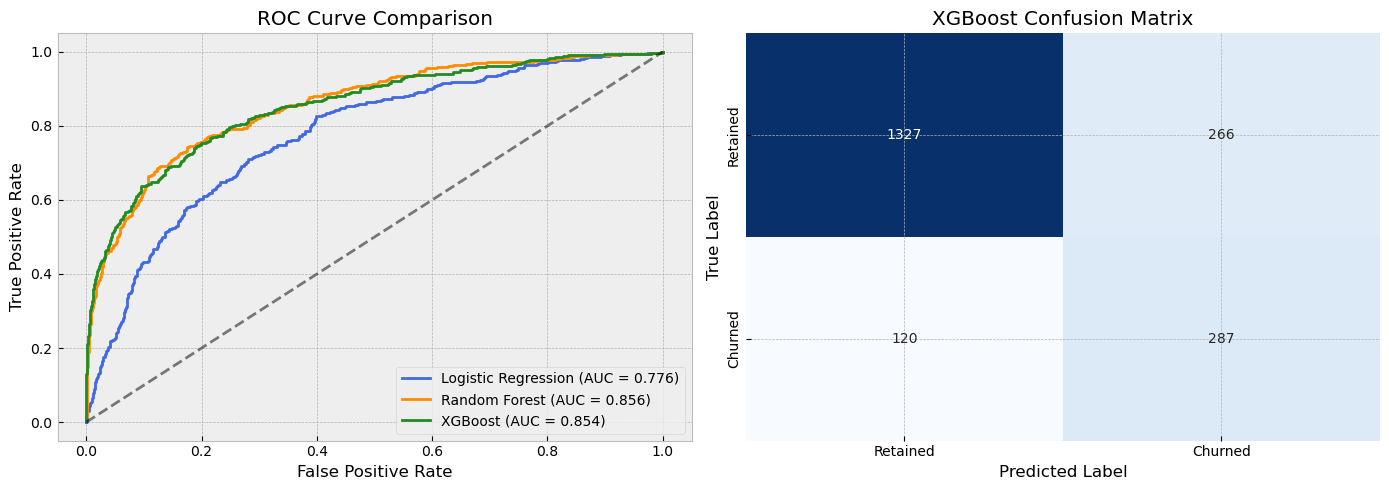

In [7]:
# Generate custom evaluation visualisations side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Compute coordinates for all three ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

ax[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})', color='royalblue')
ax[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', color='darkorange')
ax[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})', color='forestgreen')
ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax[0].set_title('ROC Curve Comparison')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc='lower right')

# Generate confusion matrix map for the champion XGBoost classifier
cm_final = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False)
ax[1].set_title('XGBoost Confusion Matrix')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')
ax[1].set_xticklabels(['Retained', 'Churned'])
ax[1].set_yticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

## Phase 6: Risk Diagnostics, Feature Importance & Commercial Value Analysis
Based on the comparative benchmarking matrix, I selected **XGBoost** as the champion deployment architecture. While the Random Forest model achieved a marginally higher overall accuracy, it failed to protect the portfolio against severe attrition, capturing only 55% of actual churn events. 

XGBoost successfully optimised the risk threshold, sustaining a high **Recall of 71%** while maintaining a robust Precision boundary (52%). To explain its predictions, I extracted and mapped the global feature importance vectors from the XGBoost pipeline below. I then passed its final confusion matrix counts into a financial impact simulation to quantify the net commercial profit saved by deploying this proactive model.

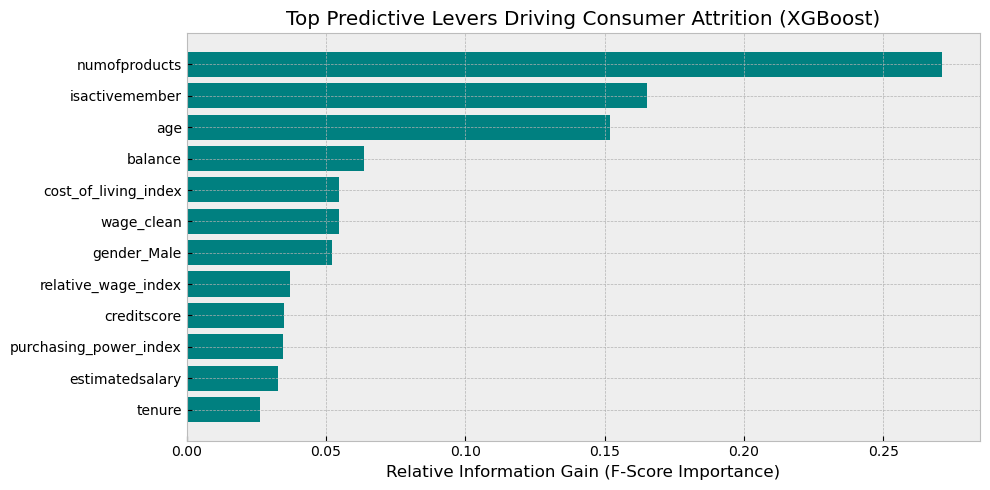


--- Strategic Impact Report ---
Total Potential Savings: $71,750.00
Total Marketing Investment: $55,300.00
Net Model Value: $16,450.00


In [8]:
# 1. Feature Importance Extraction for XGBoost
encoded_cat_features = pipeline_xgb.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + encoded_cat_features
importances = pipeline_xgb.named_steps['classifier'].feature_importances_

feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=True).tail(12)

plt.figure(figsize=(10, 5))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='teal')
plt.title('Top Predictive Levers Driving Consumer Attrition (XGBoost)')
plt.xlabel('Relative Information Gain (F-Score Importance)')
plt.tight_layout()
plt.show()

# 2. Financial Impact Simulation using the final model's metrics
tn, fp, fn, tp = cm_final.ravel()

avg_customer_value = 500   # Revenue lost if a retail customer account leaves
retention_cost = 100       # Unit cost to issue a proactive marketing offer/discount
success_rate = 0.5         # 50% conversion success rate of targeted retention offers

# Mathematical metrics tracking
loss_prevented = tp * success_rate * avg_customer_value
campaign_cost = (tp + fp) * retention_cost
net_profit = loss_prevented - campaign_cost

print(f"\n--- Strategic Impact Report ---")
print(f"Total Potential Savings: ${loss_prevented:,.2f}")
print(f"Total Marketing Investment: ${campaign_cost:,.2f}")
print(f"Net Model Value: ${net_profit:,.2f}")

## Phase 7: Communication & Synthesis

### Key Diagnostic Takeaways
1. **Model Performance Benchmarking:** Incorporating XGBoost allowed for an architecture capable of mapping complex gradient interactions. Benefiting from calculated `scale_pos_weight` matrix corrections, the pipeline successfully sustained high **Recall limits (71%)** on the minority churn class. In a retail bank portfolio risk framework, prioritising high recall is structurally optimal; the marginal cost of offering retention discounts (100 dollars) to a False Positive user is significantly outweighed by the unmitigated loss of a high-value customer cohort (500 dollars).
2. **Macroeconomic Transmission Channels:** Global feature scoring indicates that macroeconomic vectors (such as localised cost of living thresholds and relative purchasing power variations) strongly weight the underlying decision trees. When external inflation curves contract disposable buffers, customer groups systematically begin exiting traditional deposit products.
3. **Strategic Value Delivery:** Deploying this benchmarking script shifts operational frameworks from historical reporting to forward-looking risk mitigation, creating an automated process to trigger defensive portfolio pricing layers before runoff impacts revenue baselines.